# Librerias

In [31]:
import pandas as pd
import numpy as np
from kmodes.kmodes import KModes
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de la bbdd y reducción

## 1. Cargar csv

In [32]:
#cargar datos
df = pd.read_parquet("../../data/df_limpiado_260504.parquet")

df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contactado_campania_previa
0,59,administration,married,secondary,no,2343,yes,no,unknown,5,may,1042.0,1,NaN,0,sin_campania_previa,yes,0
1,56,administration,married,secondary,no,45,no,no,unknown,5,may,1467.0,1,NaN,0,sin_campania_previa,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389.0,1,NaN,0,sin_campania_previa,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579.0,1,NaN,0,sin_campania_previa,yes,0
4,54,administration,married,tertiary,no,184,no,no,unknown,5,may,673.0,2,NaN,0,sin_campania_previa,yes,0


In [33]:
#Nos quedamos con las variables que usaremos para perfil de cliente
cols = ["age", "job", "marital", "education", "balance", "default", "housing", "loan", "deposit"]

df_perfil = df[cols].copy()
df_perfil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  string
 2   marital    11162 non-null  string
 3   education  11162 non-null  string
 4   balance    11162 non-null  int64 
 5   default    11162 non-null  string
 6   housing    11162 non-null  string
 7   loan       11162 non-null  string
 8   deposit    11162 non-null  string
dtypes: int64(2), string(7)
memory usage: 785.0 KB


# 2. Categorizar edad

In [34]:
df_perfil["age_group"] = pd.cut(df_perfil["age"], bins=[0, 25, 35, 45, 55, 65, 120], labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"])

#Eliminamos la columna numérica original
df_perfil = df_perfil.drop(columns=["age"])

# 3. Categorizar multiproducto

In [35]:
#Crear variables binarias 0/1 para cada producto
df_perfil = df_perfil.copy()

df_perfil["deposit_bin"] = (df_perfil["deposit"] == "yes").astype(int)
df_perfil["loan_bin"] = (df_perfil["loan"] == "yes").astype(int)
df_perfil["housing_bin"] = (df_perfil["housing"] == "yes").astype(int)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1


In [36]:
#Crear variable combinación, según orden de 0 y 1 se puede saber que productos
def multiproducto(row):
    return f"{row['deposit_bin']}{row['loan_bin']}{row['housing_bin']}"

df_perfil["multiproducto"] = df_perfil.apply(multiproducto, axis=1)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101


In [37]:
#Crear columna catagorica de multiproducto:
etiquetas = {
    "000": "Ningún producto",
    "100": "Solo depósitos",
    "010": "Solo préstamos",
    "001": "Solo hipotecas",
    "110": "Depósitos y préstamos",
    "101": "Depósitos y hipotecas",
    "011": "Préstamos y hipotecas",
    "111": "Todos los productos"
}

df_perfil['multiproducto_cat'] = df_perfil['multiproducto'].astype(str).map(etiquetas)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto,multiproducto_cat
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101,Depósitos y hipotecas
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100,Solo depósitos
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101,Depósitos y hipotecas


In [38]:
#Crear columna conteo de productos:
df_perfil["cantidad_prod"] = df_perfil["deposit_bin"] + df_perfil["loan_bin"] + df_perfil["housing_bin"]

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto,multiproducto_cat,cantidad_prod
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101,Depósitos y hipotecas,2
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100,Solo depósitos,1
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101,Depósitos y hipotecas,2


In [39]:
#Crear columna multiproducto binaria:
df_perfil["multiproducto_bin"] = (df_perfil["cantidad_prod"] > 1).astype(int)

df_perfil.head(3)

,job,marital,education,balance,default,housing,loan,deposit,age_group,deposit_bin,loan_bin,housing_bin,multiproducto,multiproducto_cat,cantidad_prod,multiproducto_bin
0,administration,married,secondary,2343,no,yes,no,yes,56-65,1,0,1,101,Depósitos y hipotecas,2,1
1,administration,married,secondary,45,no,no,no,yes,56-65,1,0,0,100,Solo depósitos,1,0
2,technician,married,secondary,1270,no,yes,no,yes,36-45,1,0,1,101,Depósitos y hipotecas,2,1


# 4. Clústering

In [40]:
#dataset para modelo:
cols_modelo = ["age_group", "job", "marital", "education"]
df_perfil_m = df_perfil[cols_modelo].copy()
data_model = df_perfil_m.copy()
X = data_model.to_numpy()

#Entrenar modelo:
k_opt = 5
km = KModes(n_clusters=k_opt, init='Cao', n_init=5, verbose=0)
clusters = km.fit_predict(X)

#Añadir columna clúster a dataset original:
df_perfil["cluster"] = clusters
df_perfil["cluster"].value_counts().sort_index()

cluster
0    5641
1    1781
2    1233
3    1014
4    1493
Name: count, dtype: int64

In [41]:
#Centroides:
centroides = km.cluster_centroids_
centroides

array([['26-35', 'management', 'married', 'secondary'],
       ['36-45', 'technician', 'single', 'tertiary'],
       ['46-55', 'technician', 'married', 'tertiary'],
       ['46-55', 'administration', 'single', 'secondary'],
       ['36-45', 'blue-collar', 'married', 'primary']], dtype='<U14')

In [42]:
# Moda por clúster
multiproducto_moda = (
    df_perfil.groupby("cluster")["multiproducto_cat"]
    .agg(lambda x: x.mode().iloc[0])
    .sort_index()
)

# Centroides del modelo
perfil_clusters = pd.DataFrame(
    km.cluster_centroids_,
    columns=cols_modelo,
    index=[f"Cluster {i}" for i in range(km.n_clusters)]
)

# Añadir moda
perfil_clusters["multiproducto_moda"] = multiproducto_moda.values

perfil_clusters

,age_group,job,marital,education,multiproducto_moda
Cluster 0,26-35,management,married,secondary,Solo depósitos
Cluster 1,36-45,technician,single,tertiary,Solo depósitos
Cluster 2,46-55,technician,married,tertiary,Solo depósitos
Cluster 3,46-55,administration,single,secondary,Solo depósitos
Cluster 4,36-45,blue-collar,married,primary,Solo hipotecas


In [43]:
#Nos quedamos con variables para estudiar productos
cols_prod = ["cluster", "age_group", "job", "marital", "education", "balance","deposit", "loan", "housing", "default", "multiproducto", "multiproducto_cat", "cantidad_prod", "multiproducto_bin"]

df_product = df_perfil[cols_prod].copy()

df_product.head(3)

,cluster,age_group,job,marital,education,balance,deposit,loan,housing,default,multiproducto,multiproducto_cat,cantidad_prod,multiproducto_bin
0,0,56-65,administration,married,secondary,2343,yes,no,yes,no,101,Depósitos y hipotecas,2,1
1,0,56-65,administration,married,secondary,45,yes,no,no,no,100,Solo depósitos,1,0
2,0,36-45,technician,married,secondary,1270,yes,no,yes,no,101,Depósitos y hipotecas,2,1


# 5. Análisis descriptivo

In [51]:
# Tabla de contingencia Clúster vs Multiproducto
resumen = pd.crosstab(df_perfil['cluster'], df_perfil['multiproducto_bin'], normalize='index') * 100
resumen


multiproducto_bin,0,1
cluster,,
0,74.703067,25.296933
1,76.530039,23.469961
2,80.859692,19.140308
3,72.485207,27.514793
4,75.619558,24.380442


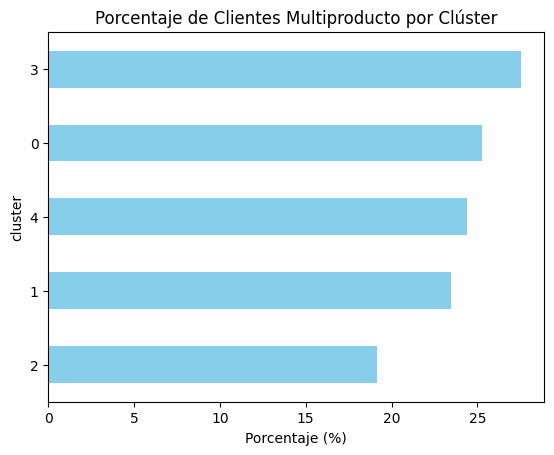

In [52]:
resumen[1].sort_values().plot(kind='barh', color='skyblue')
plt.title('Porcentaje de Clientes Multiproducto por Clúster')
plt.xlabel('Porcentaje (%)')
plt.show()

## Vision general

In [ ]:

#Estadística descriptiva de la cantidad de productos
print("--- Estadísticas de Cantidad de Productos ---")
print(df_perfil['cantidad_prod'].describe())

# Media de productos por grupo de edad (Opcional pero muy útil)
print("\n--- Media de productos por Rango de Edad ---")
print(df_perfil.groupby('age_group')['cantidad_prod'].mean().sort_values(ascending=False))

--- Estadísticas de Cantidad de Productos ---
count    11162.000000
mean         1.077764
std          0.706600
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: cantidad_prod, dtype: float64

--- Media de productos por Rango de Edad ---
age_group
26-35    1.148724
<=25     1.124722
36-45    1.106262
46-55    0.998137
56-65    0.959484
65+      0.851759
Name: cantidad_prod, dtype: float64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16628\1533721255.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_perfil.groupby('age_group')['cantidad_prod'].mean().sort_values(ascending=False))


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16628\990359439.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')


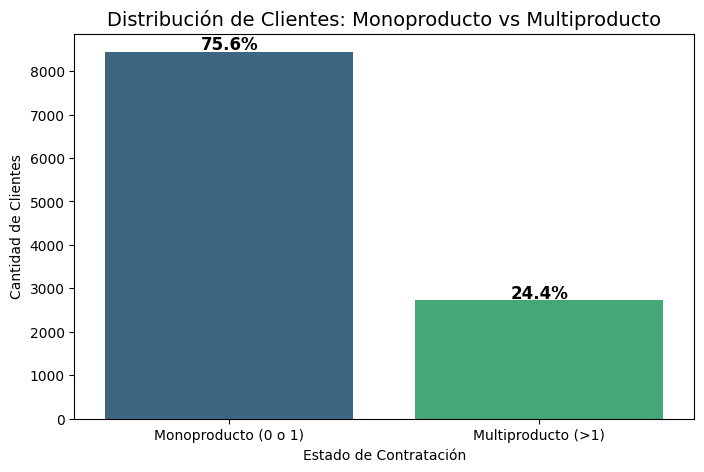

In [ ]:
# Distribución de Multiproducto (Binario)
counts = df_perfil['multiproducto_bin'].value_counts()
percentages = df_perfil['multiproducto_bin'].value_counts(normalize=True) * 100

# gráfico de barras
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=counts.index, y=counts.values, palette='viridis')

for i, p in enumerate(percentages):
    ax.annotate(f'{p:.1f}%', (i, counts.values[i] + 50), ha='center', fontsize=12, fontweight='bold')

plt.title('Distribución de Clientes: Monoproducto vs Multiproducto', fontsize=14)
plt.xticks([0, 1], ['Monoproducto (0 o 1)', 'Multiproducto (>1)'])
plt.ylabel('Cantidad de Clientes')
plt.xlabel('Estado de Contratación')
plt.show()


## Análisis por combinaciones

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16628\2048565418.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


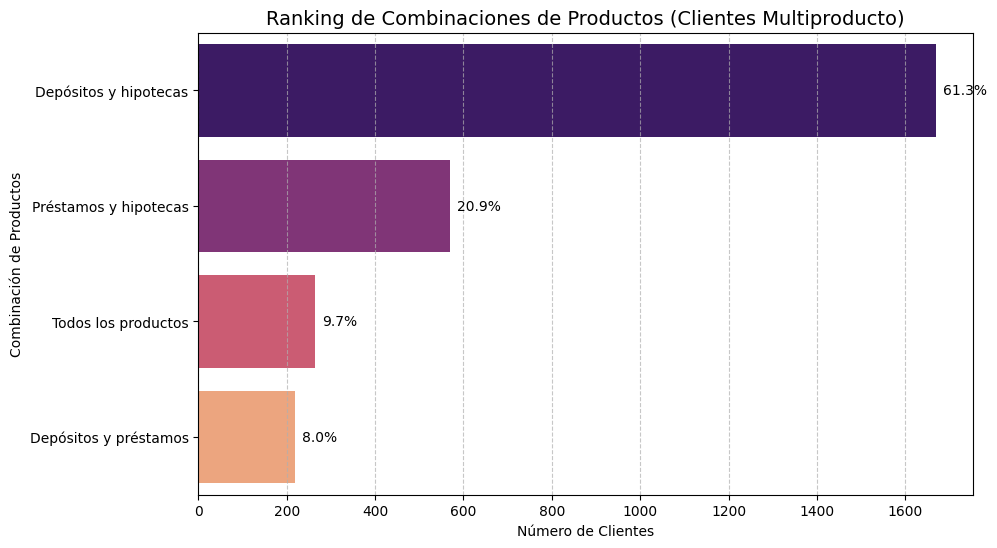

--- Detalle de Combinaciones ---
multiproducto_cat
Depósitos y hipotecas    1670
Préstamos y hipotecas     570
Todos los productos       265
Depósitos y préstamos     219
Name: count, dtype: int64


In [59]:
# 1. Filtrar solo a los clientes multiproducto para ver qué combinaciones tienen
df_multipro = df_perfil[df_perfil['multiproducto_bin'] == 1]

# 2. Conteo de combinaciones (usando la columna que ya creaste)
combinaciones_counts = df_multipro['multiproducto_cat'].value_counts()
combinaciones_percent = df_multipro['multiproducto_cat'].value_counts(normalize=True) * 100

# 3. Visualización de las combinaciones más frecuentes
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x=combinaciones_counts.values, 
    y=combinaciones_counts.index, 
    palette='magma'
)

# Añadir etiquetas de porcentaje al final de cada barra
for i, p in enumerate(combinaciones_percent):
    ax.annotate(f'{p:.1f}%', (combinaciones_counts.values[i], i), 
                va='center', xytext=(5, 0), textcoords='offset points')

plt.title('Ranking de Combinaciones de Productos (Clientes Multiproducto)', fontsize=14)
plt.xlabel('Número de Clientes')
plt.ylabel('Combinación de Productos')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 4. Tabla de resumen para el informe
print("--- Detalle de Combinaciones ---")
print(combinaciones_counts)

 ## Clúster vs multiproducto

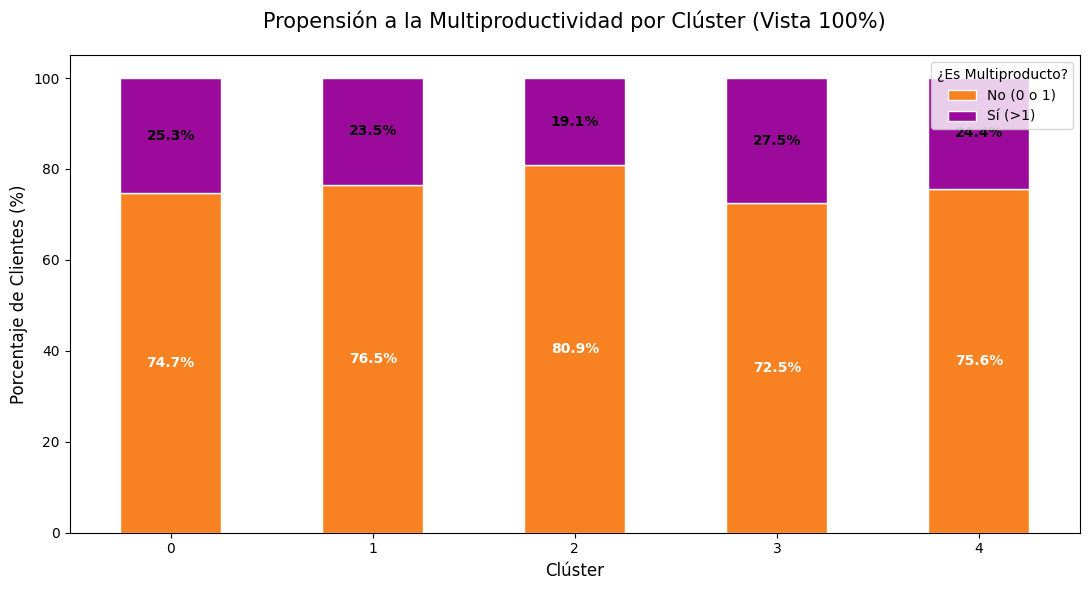

In [63]:
cross_tab = pd.crosstab(df_perfil['cluster'], df_perfil['multiproducto_bin'], normalize='index') * 100

# 2. Graficar barras apiladas
ax = cross_tab.plot(kind='bar', 
                    stacked=True, 
                    figsize=(11, 6), 
                    color=["#f88221", "#9C0A9C"], # Gris para monoproducto, Verde para multiproducto
                    edgecolor='white')


plt.title('Propensión a la Multiproductividad por Clúster (Vista 100%)', fontsize=15, pad=20)
plt.legend(title='¿Es Multiproducto?', labels=['No (0 o 1)', 'Sí (>1)'], loc='upper right')
plt.xlabel('Clúster', fontsize=12)
plt.ylabel('Porcentaje de Clientes (%)', fontsize=12)
plt.xticks(rotation=0)


for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Solo poner etiqueta si el segmento es lo suficientemente grande
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                horizontalalignment='center', 
                verticalalignment='center',
                color='white' if height > 50 else 'black',
                fontweight='bold')

plt.tight_layout()
plt.show()

## Análisis individual

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16628\3047257535.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16628\3047257535.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16628\3047257535.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')


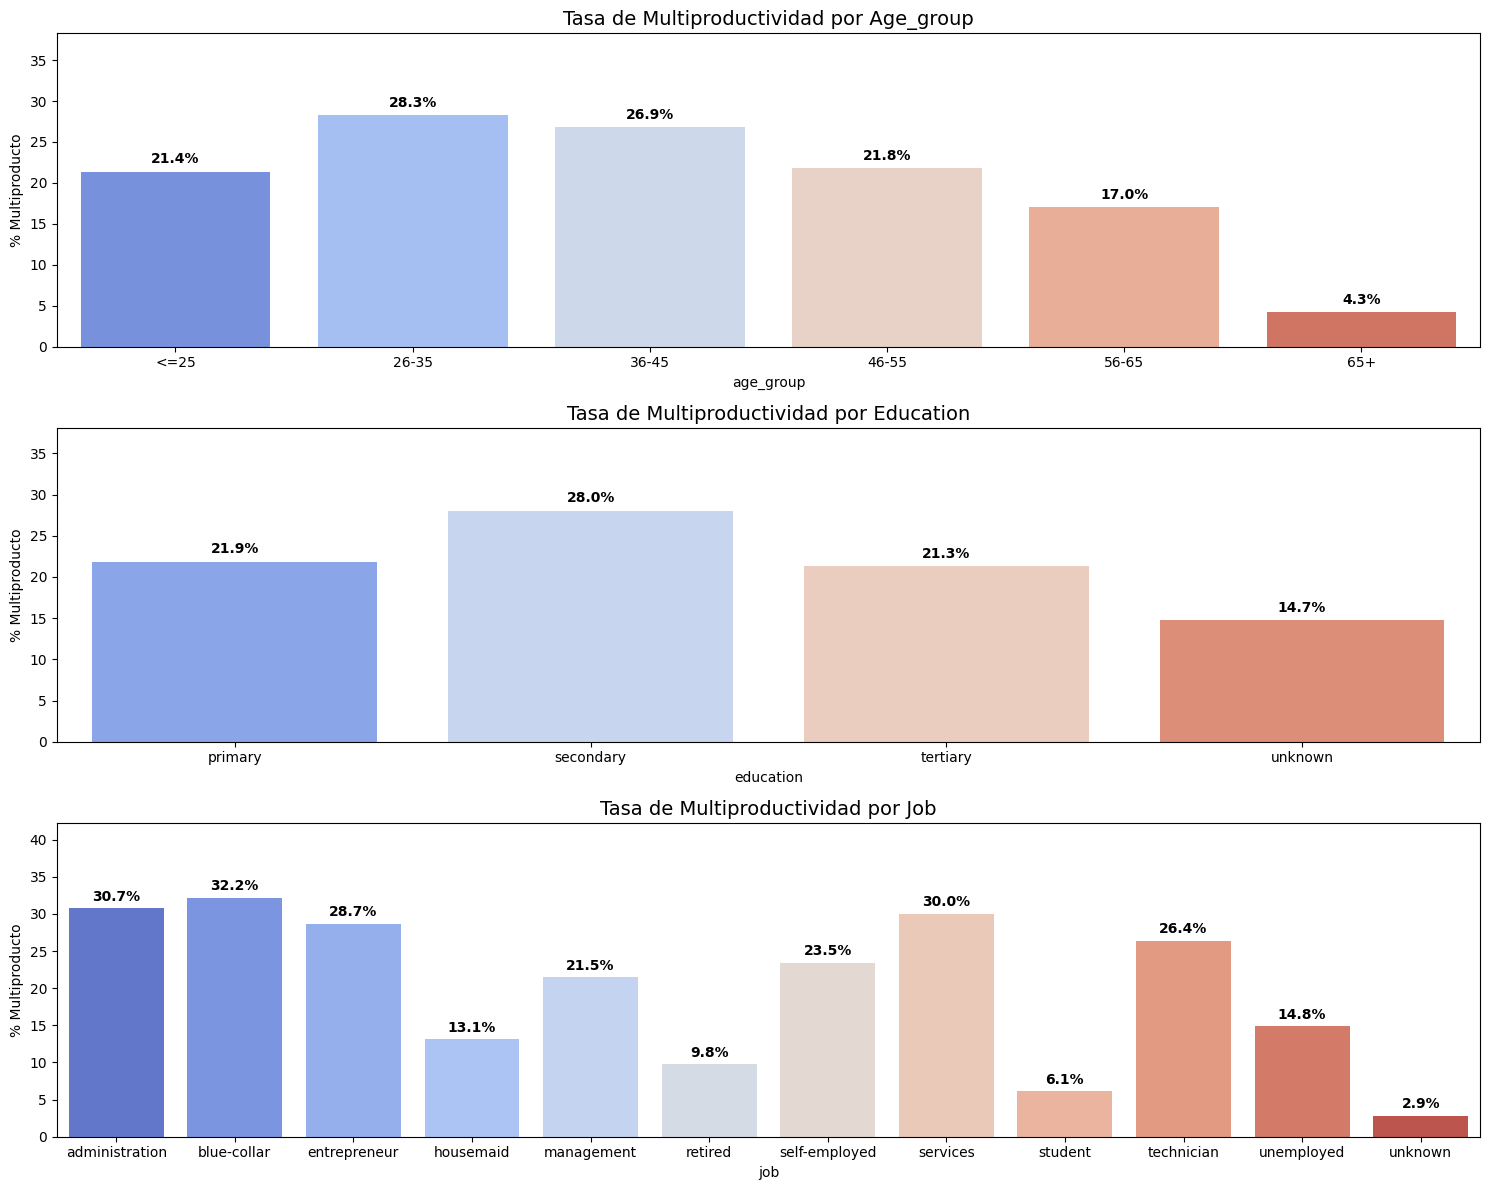

In [64]:
# Lista de variables demográficas a analizar
variables_demo = ['age_group', 'education', 'job']

plt.figure(figsize=(15, 12))

for i, var in enumerate(variables_demo, 1):
    # Crear tabla de contingencia normalizada por variable
    tabla_var = pd.crosstab(df_perfil[var], df_perfil['multiproducto_bin'], normalize='index') * 100
    
    # Crear subgráfico
    plt.subplot(3, 1, i)
    # Graficamos solo la columna '1' (quienes sí son multiproducto)
    sns.barplot(x=tabla_var.index, y=tabla_var[1], palette='coolwarm')
    
    # Personalización
    plt.title(f'Tasa de Multiproductividad por {var.capitalize()}', fontsize=14)
    plt.ylabel('% Multiproducto')
    plt.xlabel(var)
    plt.ylim(0, max(tabla_var[1]) + 10) # Espacio para etiquetas
    
    # Añadir valores sobre las barras
    for index, value in enumerate(tabla_var[1]):
        plt.text(index, value + 1, f'{value:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Regresión logística binaria

In [ ]:
'''
X = df_product[['cluster','age_group','job','marital','education',
                'balance','deposit','loan','housing','default']]

# Convertir categóricas a dummies
X = pd.get_dummies(X, drop_first=True)

# Asegurar que todo sea numérico
X = X.apply(pd.to_numeric, errors='coerce')

# Eliminar filas con NA
X = X.dropna()
y = df_product.loc[X.index, 'multiproducto_bin']

# Agregar constante
X = sm.add_constant(X)

modelo = sm.Logit(y, X).fit()
print(modelo.summary())
'''


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [68]:
# Seleccionamos las variables independientes (X) y la dependiente (y)
# Incluimos los clusters y variables individuales clave
X = df_perfil[['cluster', 'age_group', 'education', 'job']]
y = df_perfil['multiproducto_bin'].astype(float)
# Convertimos a variables dummy
# drop_first=True elimina automáticamente una categoría para que sirva de referencia
X_dummies = pd.get_dummies(X, drop_first=True, dtype=float)

# Añadimos la constante (intercepto) que requiere statsmodels
X_dummies = sm.add_constant(X_dummies)

# Ajustamos el modelo logístico
modelo = sm.Logit(y, X_dummies)
resultado = modelo.fit()

# Mostramos el resumen
print(resultado.summary())

# Calculamos los Odds Ratios
odds_ratios = np.exp(resultado.params)
print("--- Odds Ratios ---")
print(odds_ratios)


Optimization terminated successfully.
         Current function value: 0.533636
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:      multiproducto_bin   No. Observations:                11162
Model:                          Logit   Df Residuals:                    11141
Method:                           MLE   Df Model:                           20
Date:                Wed, 06 May 2026   Pseudo R-squ.:                 0.03970
Time:                        16:03:49   Log-Likelihood:                -5956.4
converged:                       True   LL-Null:                       -6202.7
Covariance Type:            nonrobust   LLR p-value:                 1.112e-91
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -0.7367      0.189     -3.893      0.000      -1.108      -0.366
cl

In [69]:
params = resultado.params
conf = resultado.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
print(np.exp(conf))

                         2.5%     97.5%  Odds Ratio
const                0.330375  0.693620    0.478701
cluster              0.955778  1.043787    0.998814
age_group_26-35      0.732741  1.244324    0.954865
age_group_36-45      0.661677  1.120214    0.860941
age_group_46-55      0.514840  0.886167    0.675451
age_group_56-65      0.416350  0.775449    0.568206
age_group_65+        0.088815  0.299634    0.163131
education_secondary  0.972341  1.398633    1.166168
education_tertiary   0.744432  1.111327    0.909564
education_unknown    0.549098  1.002182    0.741820
job_blue-collar      0.940898  1.291913    1.102524
job_entrepreneur     0.786894  1.366995    1.037150
job_housemaid        0.293024  0.630165    0.429713
job_management       0.615097  0.903982    0.745679
job_retired          0.404766  0.768967    0.557899
job_self-employed    0.593630  1.018695    0.777642
job_services         0.779073  1.141363    0.942977
job_student          0.086338  0.219852    0.137773
job_technici

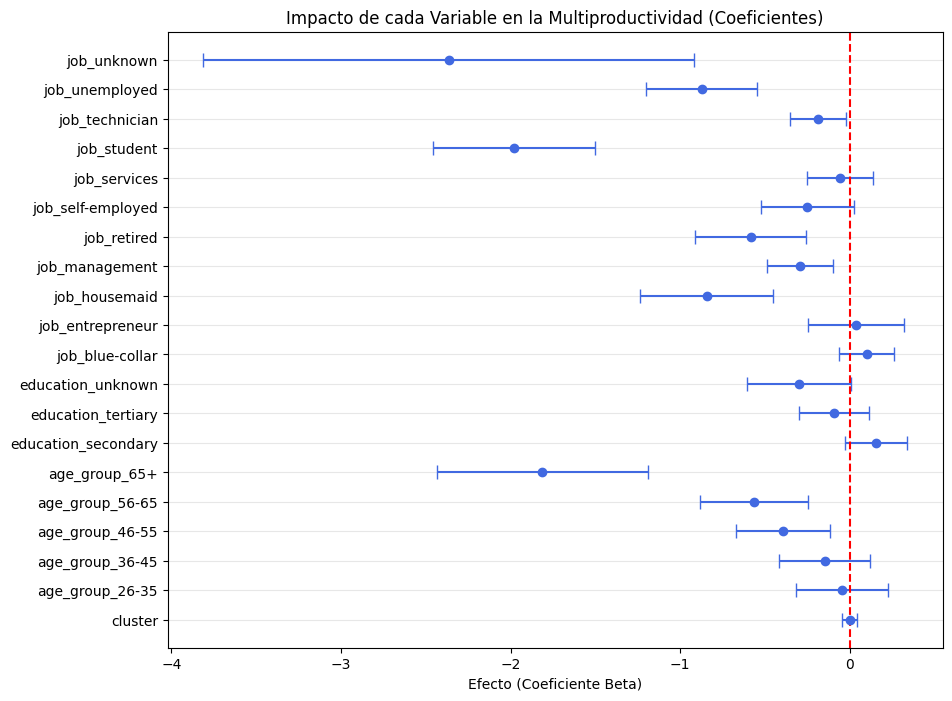

In [70]:
# Extraer coeficientes e intervalos de confianza
df_res = pd.DataFrame({
    'coef': resultado.params,
    'error': resultado.bse,
    'p_valor': resultado.pvalues
})
# Quitamos la constante para que no arruine la escala del gráfico
df_res = df_res.drop('const')

# Graficar
plt.figure(figsize=(10, 8))
plt.errorbar(df_res['coef'], df_res.index, xerr=2*df_res['error'], fmt='o', color='royalblue', capsize=5)
plt.axvline(x=0, color='red', linestyle='--') # Línea de neutralidad
plt.title('Impacto de cada Variable en la Multiproductividad (Coeficientes)')
plt.xlabel('Efecto (Coeficiente Beta)')
plt.grid(axis='y', alpha=0.3)
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16628\781651245.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_perfil, x='age_group', y='prob_predicha', palette='magma')


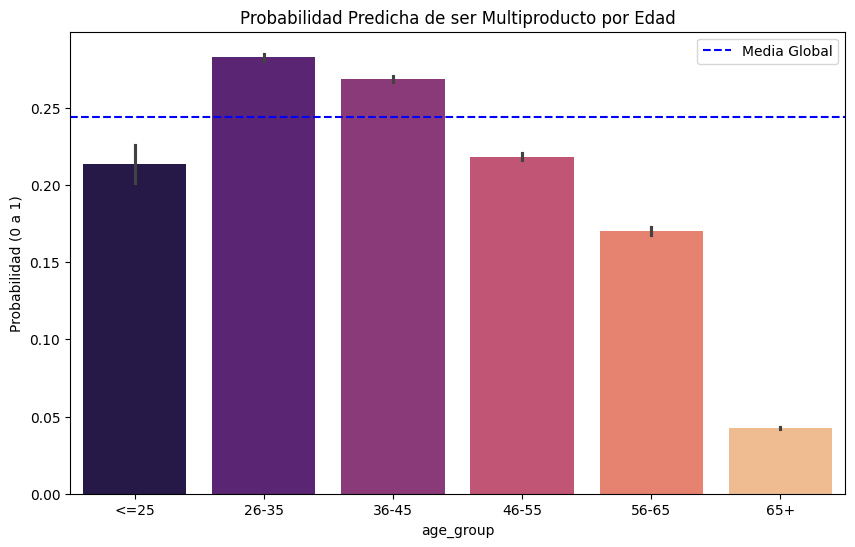

In [71]:
# Generar las probabilidades predichas del modelo
df_perfil['prob_predicha'] = resultado.predict(X_dummies)

# Graficar la probabilidad promedio por grupo de edad
plt.figure(figsize=(10, 6))
sns.barplot(data=df_perfil, x='age_group', y='prob_predicha', palette='magma')
plt.title('Probabilidad Predicha de ser Multiproducto por Edad')
plt.ylabel('Probabilidad (0 a 1)')
plt.axhline(df_perfil['multiproducto_bin'].mean(), color='blue', linestyle='--', label='Media Global')
plt.legend()
plt.show()

# 7. Conclusiones